<a href="https://colab.research.google.com/github/dariakadina/satprak/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проект: прогнозирование успеваемости студентов

## Основные задачи

1. **Регрессия:** предсказать итоговую оценку студента `G3`.
2. **Классификация:** предсказать, сдаст ли студент предмет: `pass_exam = 1`, если `G3 >= 10`.

## Модели

Для регрессии:

- Linear Regression;
- KNN Regressor;
- Random Forest Regressor.

Для классификации:

- Logistic Regression;
- KNN Classifier;
- Random Forest Classifier.


## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

## 2. Загрузка данных



In [2]:
DATA_DIR = Path(".")

mat_path = DATA_DIR / "student-mat.csv"
por_path = DATA_DIR / "student-por.csv"


assert mat_path.exists(), "Файл student-mat.csv не найден. Загрузите его рядом с ноутбуком."
assert por_path.exists(), "Файл student-por.csv не найден. Загрузите его рядом с ноутбуком."

mat = pd.read_csv(mat_path, sep=";")
por = pd.read_csv(por_path, sep=";")

mat["subject"] = "math"
por["subject"] = "portuguese"

df = pd.concat([mat, por], ignore_index=True)

print("Размер объединенного датасета:", df.shape)
df.head()

Размер объединенного датасета: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,math


## 3. Краткая проверка данных



In [3]:
print("Количество строк и столбцов:", df.shape)
print("Количество пропусков:", df.isna().sum().sum())
print("Количество полных дубликатов:", df.duplicated().sum())

df.info()

Количество строк и столбцов: (1044, 34)
Количество пропусков: 0
Количество полных дубликатов: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   obje

## 4. Описание целевых переменных

В датасете есть три оценки:

- `G1` — оценка за первый период;
- `G2` — оценка за второй период;
- `G3` — финальная оценка.

В основной задаче регрессии целевая переменная — `G3`.

Также создадим бинарную целевую переменную для классификации:

\[
pass\_exam = 1, \ если \ G3 \geq 10
\]



Доля сдавших предмет:
pass_exam
1    0.78
0    0.22
Name: proportion, dtype: float64


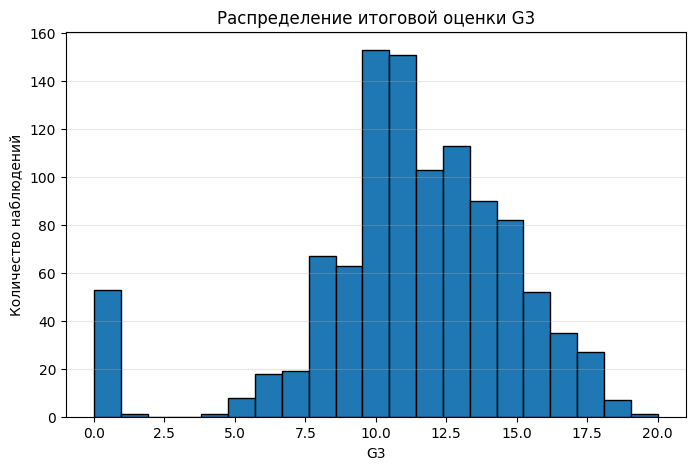

In [4]:
df["pass_exam"] = (df["G3"] >= 10).astype(int)

print("Доля сдавших предмет:")
print(df["pass_exam"].value_counts(normalize=True).round(3))

plt.figure(figsize=(8, 5))
plt.hist(df["G3"], bins=21, edgecolor="black")
plt.title("Распределение итоговой оценки G3")
plt.xlabel("G3")
plt.ylabel("Количество наблюдений")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 5. Функции для подготовки данных и оценки моделей

In [5]:
def make_preprocessor(X):
    """
    Создает общий препроцессор для числовых и категориальных признаков.
    Числовые признаки: заполнение медианой + стандартизация.
    Категориальные признаки: заполнение модой + One-Hot Encoding.
    """
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    # Для совместимости с разными версиями sklearn
    try:
        one_hot = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    except TypeError:
        one_hot = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot)
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor, numeric_features, categorical_features


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Часть I. Регрессия: прогноз итоговой оценки `G3`

## 6. Постановка задачи регрессии

Цель — предсказать итоговую оценку студента `G3` по данным о студенте, семье, школе, поведении, пропусках и предыдущих оценках.

В качестве признаков используются все переменные, кроме:

- `G3`, потому что это целевая переменная;
- `pass_exam`, потому что она создана на основе `G3` и вызовет утечку данных.

`G1` и `G2` оставляем как признаки, потому что это предыдущие оценки, известные до финального результата. Такая постановка отражает задачу прогнозирования финальной оценки по ранней успеваемости.

In [6]:
target_reg = "G3"

features_reg = [col for col in df.columns if col not in ["G3", "pass_exam"]]

X_reg = df[features_reg]
y_reg = df[target_reg]

print("Количество признаков:", X_reg.shape[1])
X_reg.head()

Количество признаков: 33


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,math
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,math
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,math


## 7. Train-test split

In [7]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Размер train:", X_train_reg.shape)
print("Размер test:", X_test_reg.shape)

Размер train: (835, 33)
Размер test: (209, 33)


## 8. Обучение регрессионных моделей

Обучаем три модели:

1. **Linear Regression** — простая линейная модель.
2. **KNN Regressor** — модель ближайших соседей.
3. **Random Forest Regressor** — ансамблевая модель на решающих деревьях.

Для KNN и Random Forest подбираем гиперпараметры через `GridSearchCV`. Основная метрика для подбора — MAE, потому что она показывает среднюю ошибку прогноза в баллах.

In [8]:
preprocessor_reg, numeric_features_reg, categorical_features_reg = make_preprocessor(X_reg)

regression_models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 15],
            "model__min_samples_leaf": [1, 3, 5]
        }
    }
}

regression_results = []
best_regression_models = {}

for model_name, model_info in regression_models.items():
    print(f"Обучается модель: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_reg),
        ("model", model_info["model"])
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=model_info["params"],
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train_reg, y_train_reg)

    best_model = grid_search.best_estimator_
    best_regression_models[model_name] = best_model

    y_train_pred = best_model.predict(X_train_reg)
    y_test_pred = best_model.predict(X_test_reg)

    regression_results.append({
        "model": model_name,
        "best_params": grid_search.best_params_,
        "CV_MAE": -grid_search.best_score_,
        "MAE_train": mean_absolute_error(y_train_reg, y_train_pred),
        "MAE_test": mean_absolute_error(y_test_reg, y_test_pred),
        "RMSE_train": rmse(y_train_reg, y_train_pred),
        "RMSE_test": rmse(y_test_reg, y_test_pred),
        "R2_train": r2_score(y_train_reg, y_train_pred),
        "R2_test": r2_score(y_test_reg, y_test_pred)
    })

regression_results_df = pd.DataFrame(regression_results)
regression_results_df

Обучается модель: Linear Regression
Обучается модель: KNN
Обучается модель: Random Forest


,model,best_params,CV_MAE,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
0,Linear Regression,{},0.970928,9.232356e-01,1.016888,1.466231e+00,1.759933,0.854369,0.799664
1,KNN,"{'model__n_neighbors': 15, 'model__p': 2, 'mod...",1.496957,7.523987e-08,1.636504,2.755543e-07,2.468264,1.000000,0.605951
2,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.854681,5.969678e-01,0.888021,1.025197e+00,1.595061,0.928803,0.835441


## 9. Сравнение регрессионных моделей

In [9]:
regression_results_df_sorted = regression_results_df.sort_values("MAE_test")
regression_results_df_sorted

,model,best_params,CV_MAE,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test
2,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.854681,5.969678e-01,0.888021,1.025197e+00,1.595061,0.928803,0.835441
0,Linear Regression,{},0.970928,9.232356e-01,1.016888,1.466231e+00,1.759933,0.854369,0.799664
1,KNN,"{'model__n_neighbors': 15, 'model__p': 2, 'mod...",1.496957,7.523987e-08,1.636504,2.755543e-07,2.468264,1.000000,0.605951


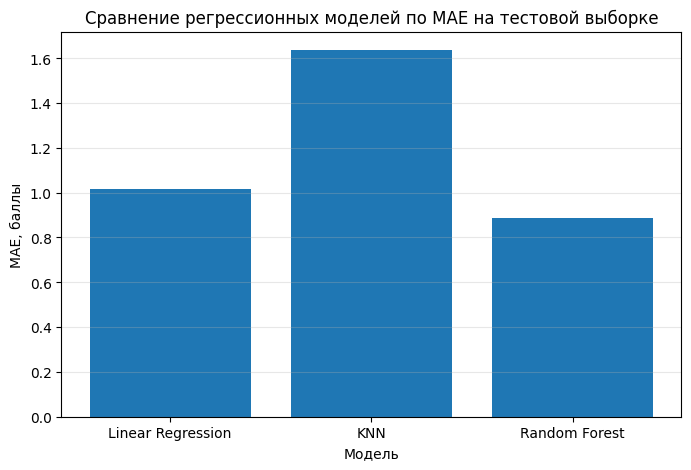

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(regression_results_df["model"], regression_results_df["MAE_test"])
plt.title("Сравнение регрессионных моделей по MAE на тестовой выборке")
plt.xlabel("Модель")
plt.ylabel("MAE, баллы")
plt.grid(axis="y", alpha=0.3)
plt.show()

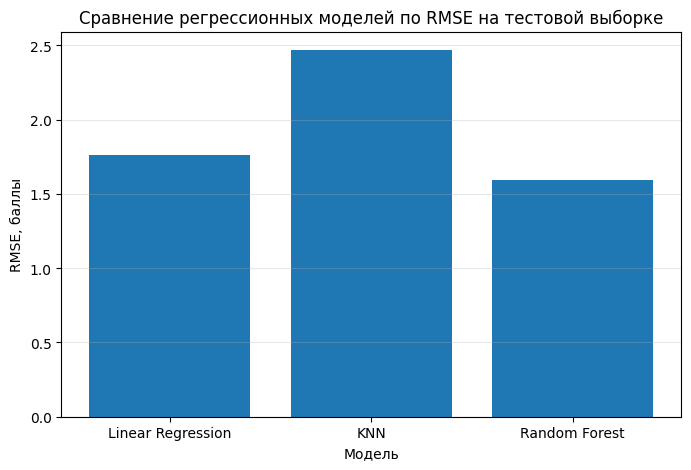

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(regression_results_df["model"], regression_results_df["RMSE_test"])
plt.title("Сравнение регрессионных моделей по RMSE на тестовой выборке")
plt.xlabel("Модель")
plt.ylabel("RMSE, баллы")
plt.grid(axis="y", alpha=0.3)
plt.show()

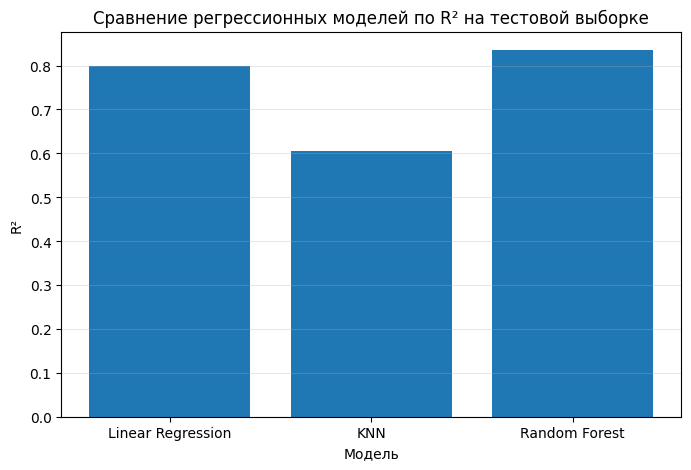

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(regression_results_df["model"], regression_results_df["R2_test"])
plt.title("Сравнение регрессионных моделей по R² на тестовой выборке")
plt.xlabel("Модель")
plt.ylabel("R²")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 10. Анализ лучшей регрессионной модели

Лучшая регрессионная модель по MAE: Random Forest


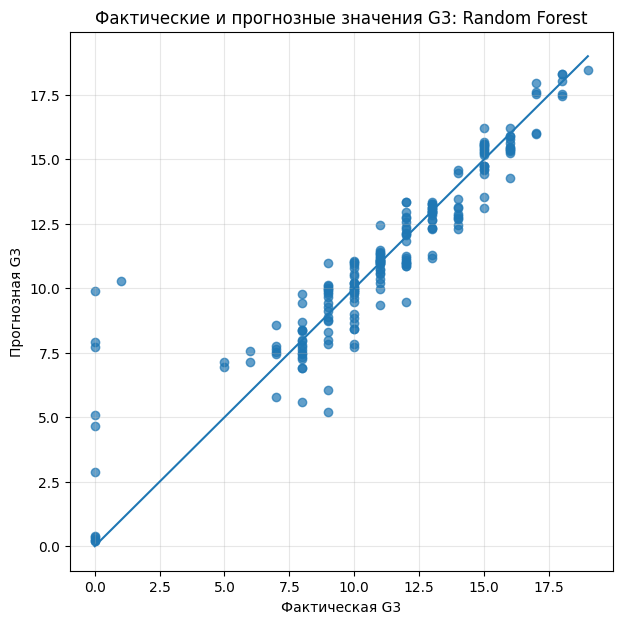

In [13]:
best_reg_model_name = regression_results_df.sort_values("MAE_test").iloc[0]["model"]
best_reg_model = best_regression_models[best_reg_model_name]

print("Лучшая регрессионная модель по MAE:", best_reg_model_name)

y_test_pred_best = best_reg_model.predict(X_test_reg)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_reg, y_test_pred_best, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()])
plt.title(f"Фактические и прогнозные значения G3: {best_reg_model_name}")
plt.xlabel("Фактическая G3")
plt.ylabel("Прогнозная G3")
plt.grid(alpha=0.3)
plt.show()

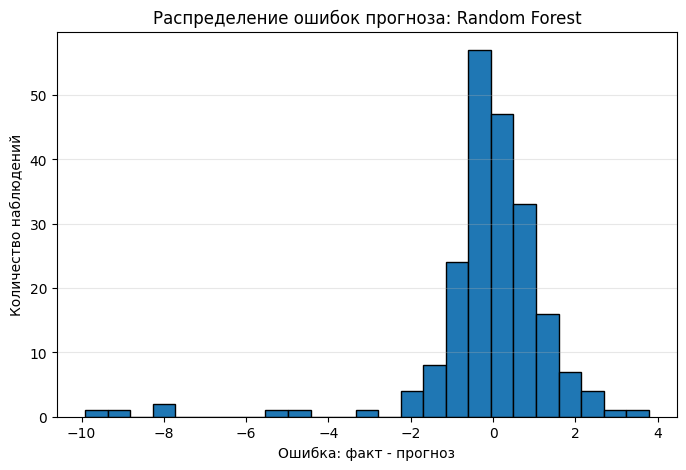

Средняя ошибка: -0.108
Медианная ошибка: -0.008
Стандартное отклонение ошибок: 1.595


In [14]:
errors_reg = y_test_reg - y_test_pred_best

plt.figure(figsize=(8, 5))
plt.hist(errors_reg, bins=25, edgecolor="black")
plt.title(f"Распределение ошибок прогноза: {best_reg_model_name}")
plt.xlabel("Ошибка: факт - прогноз")
plt.ylabel("Количество наблюдений")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Средняя ошибка:", round(errors_reg.mean(), 3))
print("Медианная ошибка:", round(np.median(errors_reg), 3))
print("Стандартное отклонение ошибок:", round(errors_reg.std(), 3))

## 11. Интерпретация признаков



In [15]:
rf_model = best_regression_models["Random Forest"]

# Имена признаков после препроцессинга
fitted_preprocessor = rf_model.named_steps["preprocessor"]

num_names = numeric_features_reg
cat_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_names = cat_encoder.get_feature_names_out(categorical_features_reg).tolist()

feature_names = num_names + cat_names
importances = rf_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
14,G2,0.881350
12,absences,0.060680
13,G1,0.007866
8,goout,0.005186
41,subject_portuguese,0.005084
4,studytime,0.004940
0,age,0.004340
16,sex_M,0.002433
10,Walc,0.002292
11,health,0.001902


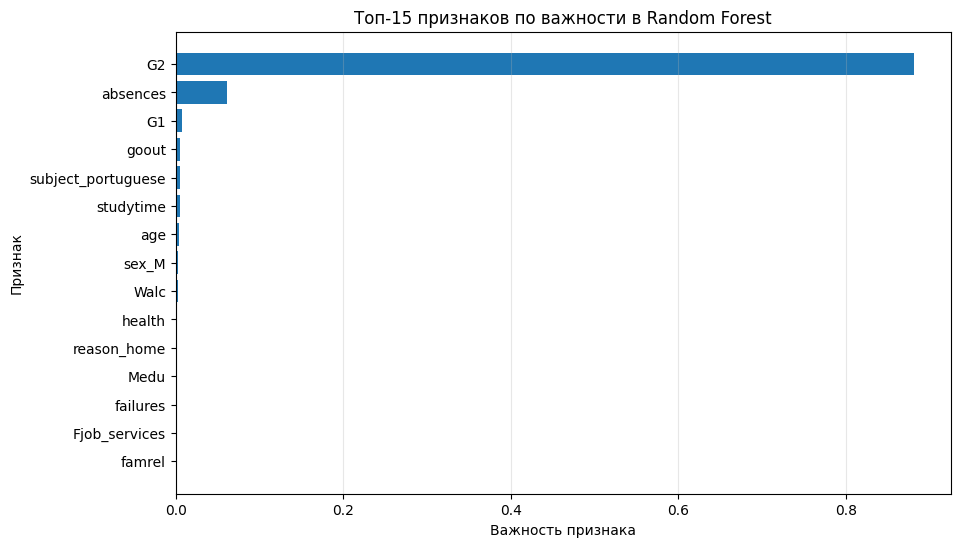

In [16]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Топ-15 признаков по важности в Random Forest")
plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

## 12. Дополнительный эксперимент: прогноз без `G1` и `G2`

Чтобы показать роль предыдущей успеваемости, обучим те же модели без признаков `G1` и `G2`.

Это более сложная постановка: мы пытаемся предсказать финальную оценку только по социально-демографическим, школьным и поведенческим признакам.

In [17]:
features_reg_without_grades = [col for col in df.columns if col not in ["G1", "G2", "G3", "pass_exam"]]

X_reg_weak = df[features_reg_without_grades]
y_reg_weak = df["G3"]

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_reg_weak,
    y_reg_weak,
    test_size=0.2,
    random_state=RANDOM_STATE
)

preprocessor_w, _, _ = make_preprocessor(X_reg_weak)

weak_results = []

for model_name, model_info in regression_models.items():
    print(f"Обучается модель без G1/G2: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_w),
        ("model", model_info["model"])
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=model_info["params"],
        scoring="neg_mean_absolute_error",
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train_w, y_train_w)

    y_test_pred_w = grid_search.best_estimator_.predict(X_test_w)

    weak_results.append({
        "model": model_name,
        "MAE_test_without_G1_G2": mean_absolute_error(y_test_w, y_test_pred_w),
        "RMSE_test_without_G1_G2": rmse(y_test_w, y_test_pred_w),
        "R2_test_without_G1_G2": r2_score(y_test_w, y_test_pred_w)
    })

weak_results_df = pd.DataFrame(weak_results)
weak_results_df

Обучается модель без G1/G2: Linear Regression
Обучается модель без G1/G2: KNN
Обучается модель без G1/G2: Random Forest


,model,MAE_test_without_G1_G2,RMSE_test_without_G1_G2,R2_test_without_G1_G2
0,Linear Regression,2.617497,3.691612,0.118546
1,KNN,2.589643,3.558644,0.180900
2,Random Forest,2.544506,3.474682,0.219096


# Часть II. Классификация: прогноз сдачи предмета

## 13. Постановка задачи классификации

Теперь решим дополнительную задачу: предсказать, сдаст ли студент предмет.

Целевая переменная:

\[
pass\_exam = 1, \ если \ G3 \geq 10
\]

Эта задача нужна, чтобы корректно использовать метрики классификации: Accuracy, Precision, Recall и F1-score.

In [18]:
target_clf = "pass_exam"

features_clf = [col for col in df.columns if col not in ["G3", "pass_exam"]]

X_clf = df[features_clf]
y_clf = df[target_clf]

print("Распределение классов:")
print(y_clf.value_counts())
print(y_clf.value_counts(normalize=True).round(3))

Распределение классов:
pass_exam
1    814
0    230
Name: count, dtype: int64
pass_exam
1    0.78
0    0.22
Name: proportion, dtype: float64


## 14. Train-test split для классификации

Используем `stratify=y_clf`, чтобы доля сдавших и не сдавших была похожей в train и test.

In [19]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Размер train:", X_train_clf.shape)
print("Размер test:", X_test_clf.shape)
print("Доля класса 1 в train:", y_train_clf.mean().round(3))
print("Доля класса 1 в test:", y_test_clf.mean().round(3))

Размер train: (835, 33)
Размер test: (209, 33)
Доля класса 1 в train: 0.78
Доля класса 1 в test: 0.78


## 15. Обучение классификационных моделей

In [20]:
preprocessor_clf, numeric_features_clf, categorical_features_clf = make_preprocessor(X_clf)

classification_models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "params": {
            "model__C": [0.1, 1, 10]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 15],
            "model__min_samples_leaf": [1, 3, 5]
        }
    }
}

classification_results = []
best_classification_models = {}

for model_name, model_info in classification_models.items():
    print(f"Обучается модель: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor_clf),
        ("model", model_info["model"])
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=model_info["params"],
        scoring="f1",
        cv=5,
        n_jobs=-1
    )

    grid_search.fit(X_train_clf, y_train_clf)

    best_model = grid_search.best_estimator_
    best_classification_models[model_name] = best_model

    y_test_pred = best_model.predict(X_test_clf)

    classification_results.append({
        "model": model_name,
        "best_params": grid_search.best_params_,
        "Accuracy": accuracy_score(y_test_clf, y_test_pred),
        "Precision": precision_score(y_test_clf, y_test_pred, zero_division=0),
        "Recall": recall_score(y_test_clf, y_test_pred, zero_division=0),
        "F1": f1_score(y_test_clf, y_test_pred, zero_division=0)
    })

classification_results_df = pd.DataFrame(classification_results)
classification_results_df

Обучается модель: Logistic Regression
Обучается модель: KNN
Обучается модель: Random Forest


,model,best_params,Accuracy,Precision,Recall,F1
0,Logistic Regression,{'model__C': 1},0.913876,0.950311,0.938650,0.944444
1,KNN,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",0.842105,0.845745,0.975460,0.905983
2,Random Forest,"{'model__max_depth': 10, 'model__min_samples_l...",0.918660,0.950617,0.944785,0.947692


## 16. Сравнение классификационных моделей

In [21]:
classification_results_df.sort_values("F1", ascending=False)

,model,best_params,Accuracy,Precision,Recall,F1
2,Random Forest,"{'model__max_depth': 10, 'model__min_samples_l...",0.918660,0.950617,0.944785,0.947692
0,Logistic Regression,{'model__C': 1},0.913876,0.950311,0.938650,0.944444
1,KNN,"{'model__n_neighbors': 7, 'model__p': 2, 'mode...",0.842105,0.845745,0.975460,0.905983


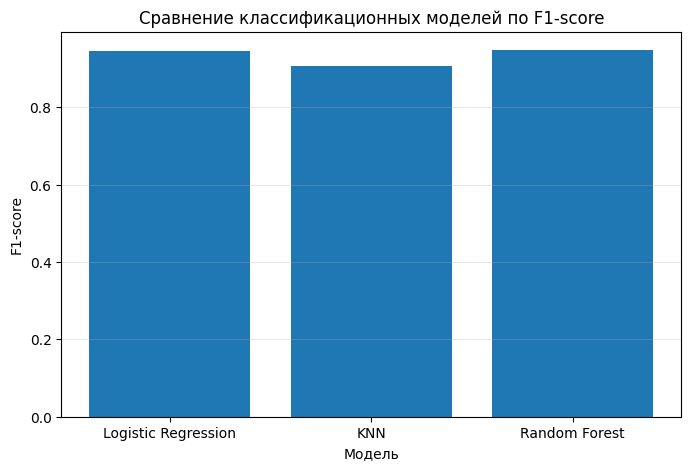

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(classification_results_df["model"], classification_results_df["F1"])
plt.title("Сравнение классификационных моделей по F1-score")
plt.xlabel("Модель")
plt.ylabel("F1-score")
plt.grid(axis="y", alpha=0.3)
plt.show()

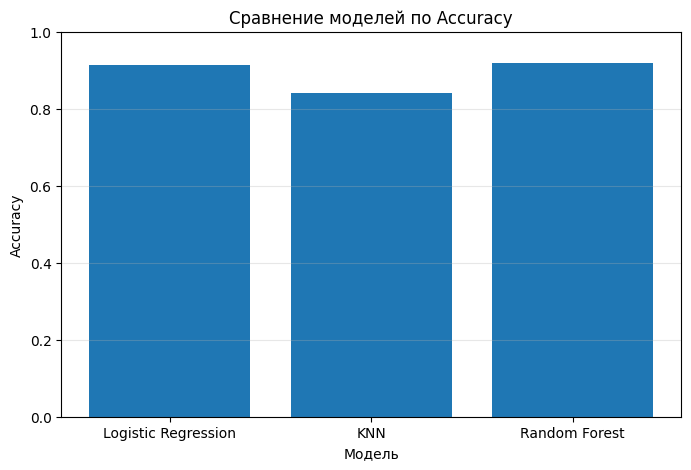

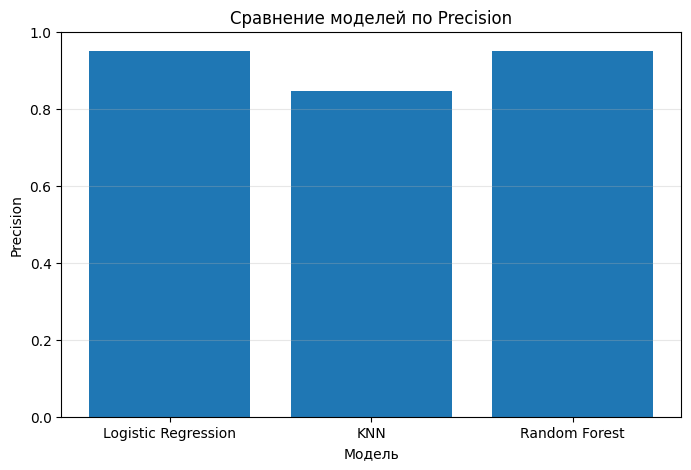

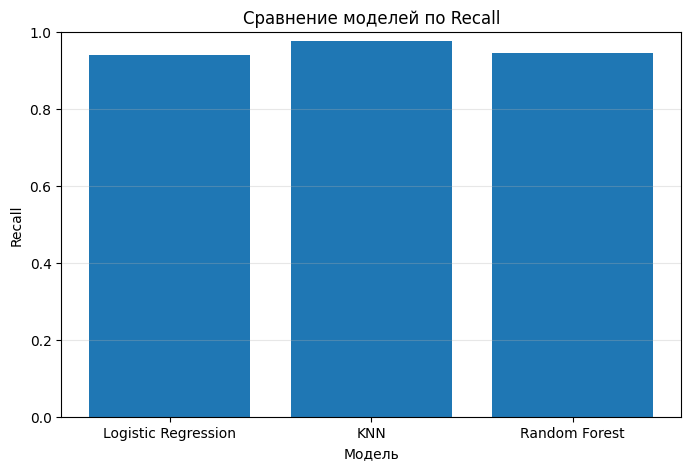

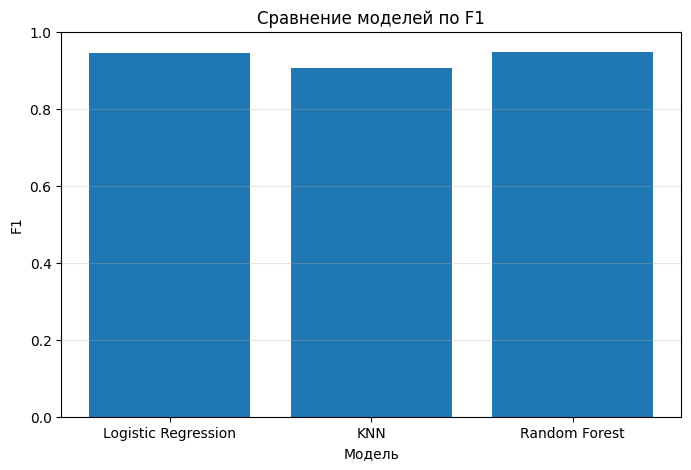

In [23]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    plt.bar(classification_results_df["model"], classification_results_df[metric])
    plt.title(f"Сравнение моделей по {metric}")
    plt.xlabel("Модель")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## 17. Матрица ошибок лучшей классификационной модели

In [24]:
best_clf_model_name = classification_results_df.sort_values("F1", ascending=False).iloc[0]["model"]
best_clf_model = best_classification_models[best_clf_model_name]

print("Лучшая классификационная модель по F1-score:", best_clf_model_name)

y_test_pred_clf = best_clf_model.predict(X_test_clf)

cm = confusion_matrix(y_test_clf, y_test_pred_clf)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

cm_df

Лучшая классификационная модель по F1-score: Random Forest


,Predicted 0,Predicted 1
Actual 0,38,8
Actual 1,9,154


In [25]:
print(classification_report(y_test_clf, y_test_pred_clf, zero_division=0))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82        46
           1       0.95      0.94      0.95       163

    accuracy                           0.92       209
   macro avg       0.88      0.89      0.88       209
weighted avg       0.92      0.92      0.92       209



# Итоговые выводы

## Регрессия

В основной задаче регрессии прогнозировалась итоговая оценка `G3`. Для этого использовались характеристики студента, семьи, школы, поведения, пропуски, предмет и предыдущие оценки `G1` и `G2`.

Модели сравнивались по метрикам:

- **MAE** — средняя ошибка прогноза в баллах;
- **RMSE** — ошибка с усиленным штрафом за крупные промахи;
- **R²** — доля объясненной вариации итоговой оценки.

Наиболее информативными признаками ожидаемо являются `G1` и `G2`, потому что они отражают предыдущую успеваемость студента. Дополнительный эксперимент без `G1` и `G2` показывает, что без предыдущих оценок качество прогноза заметно снижается.

## Классификация

В дополнительной задаче классификации прогнозировалось, сдаст ли студент предмет (`pass_exam = 1`, если `G3 >= 10`). Для оценки качества использовались:

- **Accuracy** — доля правильных классификаций;
- **Precision** — точность положительных прогнозов;
- **Recall** — доля найденных реально сдавших студентов;
- **F1-score** — баланс между Precision и Recall.

Классификация дополняет регрессионную задачу: вместо точного прогноза оценки она отвечает на более прикладной вопрос — находится ли студент в зоне риска несдачи.